# Notebook that Orchestrates the Forecasting pipeline



In [1]:
## bootstrap setup for setup on different environments (Colab, Kaggle, local)

In [2]:
from pathlib import Path
import os
import sys
import subprocess
import shutil

REPO_NAME = "Clustering-And-Forecasting-TimeSeries-PlayingGround"
REPO_URL = "https://github.com/QuirkyCroissant/Clustering-And-Forecasting-TimeSeries-PlayingGround.git"
BRANCH = "feat/cluster-forecasting-lgbm-xgb"

repo_dir = Path("/kaggle/working") / REPO_NAME

# remove old clone if it already exists and points to the wrong branch/version
if repo_dir.exists():
    shutil.rmtree(repo_dir)

subprocess.run(
    ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(repo_dir)],
    check=True
)

os.chdir(repo_dir)
REPO_ROOT = repo_dir.resolve()
PROJECT_ROOT = REPO_ROOT
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("REPO_ROOT:", REPO_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)
print("forecasting exists:", (SRC_PATH / "forecasting").exists())
print("__init__.py exists:", (SRC_PATH / "forecasting" / "__init__.py").exists())

Cloning into '/kaggle/working/Clustering-And-Forecasting-TimeSeries-PlayingGround'...


REPO_ROOT: /kaggle/working/Clustering-And-Forecasting-TimeSeries-PlayingGround
PROJECT_ROOT: /kaggle/working/Clustering-And-Forecasting-TimeSeries-PlayingGround
SRC_PATH: /kaggle/working/Clustering-And-Forecasting-TimeSeries-PlayingGround/src
forecasting exists: True
__init__.py exists: True


Updating files: 100% (63/63), done.


In [3]:
PROJECT_ROOT = REPO_ROOT
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

OUTPUT_METRICS = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_PLOTS = PROJECT_ROOT / "outputs" / "plots"
OUTPUT_PREDS = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_MODELS = PROJECT_ROOT / "outputs" / "models"

for p in [OUTPUT_METRICS, OUTPUT_PLOTS, OUTPUT_PREDS, OUTPUT_MODELS]:
    p.mkdir(parents=True, exist_ok=True)

## Importing python modules and helper functions

In [4]:
import pandas as pd
from forecasting.data import load_wide_csv, load_cluster_labels, ensure_output_dirs
from forecasting.features import make_training_frame
from forecasting.train import fit_global_model, fit_cluster_models
from forecasting.predict import forecast_global, forecast_by_group
from forecasting.evaluate import mae_by_household, summarise_mae

OUT = ensure_output_dirs(PROJECT_ROOT)

TRAIN_23_PATH = PROJECT_ROOT / "data" / "raw" / "sample_23.csv"
TEST_24_PATH  = PROJECT_ROOT / "data" / "raw" / "sample_24.csv"

# Start with one clustering output first.
# If your clustering notebook saved under notebooks/outputs/feature:
CLUSTER_PATH = PROJECT_ROOT / "notebooks" / "outputs" / "feature" / "case2_clusters.csv"

In [5]:
train_23 = load_wide_csv(TRAIN_23_PATH)
test_24 = load_wide_csv(TEST_24_PATH)
cluster_labels = load_cluster_labels(CLUSTER_PATH)

# --- Debug subsampling and progress setup ---------------------------------
# When debugging large pipelines, keep only a small fraction of rows to
# reduce memory/compute and avoid IDE variable-inspector timeouts.
DEBUG = True
DEBUG_FRAC = 0.2  # use 20% of the data for quick debugging

from tqdm.auto import tqdm
# enable pandas progress_apply / progress_map if used downstream
tqdm.pandas()

if DEBUG:
    # assume the first column in the wide frames is the ID column
    id_col_train = train_23.columns[0]
    id_col_clusters = cluster_labels.columns[0] if len(cluster_labels.columns) > 0 else id_col_train
    sampled_ids = train_23[id_col_train].sample(frac=DEBUG_FRAC, random_state=42)

    train_23 = train_23[train_23[id_col_train].isin(sampled_ids)].reset_index(drop=True)
    test_24 = test_24[test_24[id_col_train].isin(sampled_ids)].reset_index(drop=True)
    cluster_labels = cluster_labels[cluster_labels[id_col_clusters].isin(sampled_ids)].reset_index(drop=True)

    print(f"DEBUG MODE: using {int(DEBUG_FRAC*100)}% of data -> ")
    print("  train_23.shape:", train_23.shape)
    print("  test_24.shape:", test_24.shape)
    print("  cluster_labels.shape:", cluster_labels.shape)


train_df = make_training_frame(
    train_wide=train_23,
    cluster_labels=cluster_labels,
    static_features=None,   # TODO: add shapelet/static features later
    show_progress=True

)

feature_cols = [c for c in train_df.columns if c not in ["ID", "ForecastGroup", "target"]]
future_dates = pd.to_datetime(test_24.columns[1:])

print(train_df.shape)
print(feature_cols[:10])

DEBUG MODE: using 20% of data -> 
  train_23.shape: (3509, 366)
  test_24.shape: (3509, 367)
  cluster_labels.shape: (3509, 3)


Building training rows:   0%|          | 0/3509 [00:00<?, ?it/s]

(1182533, 29)
['dow', 'month', 'doy', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'lag_1', 'lag_7', 'lag_14']


## Fitting Models to data

### Light Gradient Boosting

In [6]:
#from lightgbm import LGBMRegressor
#global_lgbm = fit_global_model(train_df, feature_cols, model_name="lgbm", use_gpu=GPU_ENABLED)
#cluster_lgbm_models = fit_cluster_models(train_df, feature_cols, model_name="lgbm", min_rows=500, use_gpu=GPU_ENABLED, show_progress=True)

In [7]:
#pred_global_lgbm = forecast_global(
#    train_23_wide=train_23,
#    future_dates=future_dates,
#    model=global_lgbm,
#    show_progress=True,
#)

In [8]:
#pred_cluster_lgbm = forecast_by_group(
#    train_23_wide=train_23,
#    cluster_labels=cluster_labels,
#    future_dates=future_dates,
#    group_models=cluster_lgbm_models,
#    fallback_model=global_lgbm,
#    show_progress=True,
#)

#### Extreme Gradient Boosting 

In [18]:
GPU_ENABLED=True

In [19]:
global_xgb = fit_global_model(
    train_df,
    feature_cols,
    model_name="xgb",
    use_gpu=GPU_ENABLED,
)

[0]	validation_0-mae:5.98697
[50]	validation_0-mae:2.15858
[100]	validation_0-mae:1.98749
[150]	validation_0-mae:1.97439
[200]	validation_0-mae:1.96756
[250]	validation_0-mae:1.96364
[300]	validation_0-mae:1.95912
[350]	validation_0-mae:1.95599
[399]	validation_0-mae:1.95314


In [20]:
cluster_xgb_models = fit_cluster_models(
    train_df,
    feature_cols,
    model_name="xgb",
    min_rows=500,
    use_gpu=GPU_ENABLED,
    show_progress=True,
)

Training xgb cluster models:   0%|          | 0/10 [00:00<?, ?it/s]

Training group 0 with 140,866 rows
Training group 1 with 219,050 rows
Training group 2 with 759,261 rows
Training group 3 with 32,015 rows
Training group 4 with 674 rows
Skipping 5 because it has only 337 rows
Training group 6 with 17,861 rows
Training group 7 with 674 rows
Training group 8 with 1,348 rows
Finished 8 cluster models


In [21]:
pred_global_xgb = forecast_global(
    train_23_wide=train_23,
    future_dates=future_dates,
    model=global_xgb,
    static_features=None,
    show_progress=True,
    feature_cols=feature_cols,
)

Forecasting global:   0%|          | 0/366 [00:00<?, ?it/s]

In [22]:
pred_cluster_xgb = forecast_by_group(
    train_23_wide=train_23,
    cluster_labels=cluster_labels,
    future_dates=future_dates,
    group_models=cluster_xgb_models,
    fallback_model=global_xgb,
    static_features=None,
    show_progress=True,
    feature_cols=feature_cols,
)

Forecasting by cluster:   0%|          | 0/366 [00:00<?, ?it/s]

### Evaluating and comparing results

In [23]:
mae_global = mae_by_household(pred_global_xgb, test_24)
mae_cluster = mae_by_household(pred_cluster_xgb, test_24)

summary_global = summarise_mae(mae_global)
summary_global["model"] = "global_xgb"

summary_cluster = summarise_mae(mae_cluster)
summary_cluster["model"] = "cluster_xgb"

summary = pd.concat([summary_global, summary_cluster], ignore_index=True)
display(summary)

pred_global_xgb.to_csv(OUT["predictions"] / "pred_2024_global_xgb.csv", index=False)
pred_cluster_xgb.to_csv(OUT["predictions"] / "pred_2024_cluster_xgb.csv", index=False)
summary.to_csv(OUT["metrics"] / "mae_summary_xgb.csv", index=False)
mae_global.to_csv(OUT["metrics"] / "mae_by_household_global_xgb.csv", index=False)
mae_cluster.to_csv(OUT["metrics"] / "mae_by_household_cluster_xgb.csv", index=False)

,n_households,mean_mae,median_mae,std_mae,model
0,3509,4.670747,2.544701,7.073871,global_xgb
1,3509,4.386433,2.560100,6.469991,cluster_xgb


## plotting results

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_random_households_by_bucket_and_cluster(
    train_23_wide: pd.DataFrame,
    test_24_wide: pd.DataFrame,
    pred_cluster_wide: pd.DataFrame,
    cluster_labels: pd.DataFrame,
    mae_cluster_df: pd.DataFrame,
    pred_global_wide: pd.DataFrame | None = None,
    bucket_col: str = "SparsityBucket",
    cluster_col: str = "ForecastGroup",
    n_per_group: int = 2,
    random_state: int = 42,
    max_groups: int | None = None,
    figsize_per_row=(14, 4),
):
    """
    Plot n random households per (bucket, cluster) group.

    Each row = one (bucket, cluster) pair
    Each column = one sampled household
    """
    # Work on copies and align ID types
    train_df = train_23_wide.copy()
    test_df = test_24_wide.copy()
    pred_cluster_df = pred_cluster_wide.copy()
    meta_df = cluster_labels.copy()
    mae_df = mae_cluster_df.copy()

    for df in [train_df, test_df, pred_cluster_df, meta_df, mae_df]:
        df["ID"] = df["ID"].astype(str)

    if pred_global_wide is not None:
        pred_global_df = pred_global_wide.copy()
        pred_global_df["ID"] = pred_global_df["ID"].astype(str)
    else:
        pred_global_df = None

    # Fallback if bucket column is missing
    if bucket_col not in meta_df.columns:
        meta_df[bucket_col] = "all"

    # Keep only relevant columns
    meta_df = meta_df[["ID", bucket_col, cluster_col]].drop_duplicates()

    # Sample n households per group
    sampled = (
        meta_df.groupby([bucket_col, cluster_col], group_keys=False)
        .apply(lambda g: g.sample(n=min(n_per_group, len(g)), random_state=random_state))
        .reset_index(drop=True)
    )

    # Optional cap for very many groups
    group_keys = sampled[[bucket_col, cluster_col]].drop_duplicates()
    if max_groups is not None:
        group_keys = group_keys.head(max_groups)
        sampled = sampled.merge(group_keys, on=[bucket_col, cluster_col], how="inner")

    # Merge MAE
    sampled = sampled.merge(mae_df[["ID", "MAE"]], on="ID", how="left")

    # Prepare wide lookups
    train_lookup = train_df.set_index("ID")
    test_lookup = test_df.set_index("ID")
    pred_cluster_lookup = pred_cluster_df.set_index("ID")
    pred_global_lookup = pred_global_df.set_index("ID") if pred_global_df is not None else None

    train_dates = pd.to_datetime(train_df.columns[1:])
    test_dates = pd.to_datetime(test_df.columns[1:])

    unique_groups = sampled[[bucket_col, cluster_col]].drop_duplicates().to_records(index=False)
    n_rows = len(unique_groups)
    n_cols = n_per_group

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n_rows),
        squeeze=False,
    )

    for row_i, (bucket_value, cluster_value) in enumerate(unique_groups):
        group_sample = sampled[
            (sampled[bucket_col] == bucket_value) &
            (sampled[cluster_col] == cluster_value)
        ].reset_index(drop=True)

        for col_i in range(n_cols):
            ax = axes[row_i, col_i]

            if col_i >= len(group_sample):
                ax.axis("off")
                continue

            hh_id = group_sample.loc[col_i, "ID"]
            mae_val = group_sample.loc[col_i, "MAE"]

            train_vals = train_lookup.loc[hh_id].to_numpy(dtype=float)
            actual_vals = test_lookup.loc[hh_id].to_numpy(dtype=float)
            cluster_pred_vals = pred_cluster_lookup.loc[hh_id].to_numpy(dtype=float)

            ax.plot(train_dates, train_vals, label="2023 train")
            ax.plot(test_dates, actual_vals, label="2024 actual")
            ax.plot(test_dates, cluster_pred_vals, label="2024 cluster forecast")

            if pred_global_lookup is not None and hh_id in pred_global_lookup.index:
                global_pred_vals = pred_global_lookup.loc[hh_id].to_numpy(dtype=float)
                ax.plot(test_dates, global_pred_vals, label="2024 global forecast", linestyle="--")

            ax.axvline(test_dates[0], linestyle="--", linewidth=1)
            ax.set_title(
                f"ID={hh_id} | bucket={bucket_value} | cluster={cluster_value} | MAE={mae_val:.3f}"
            )
            ax.legend(loc="best")
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return sampled, fig

In [33]:
print(cluster_labels.columns.tolist())

['ID', 'RefinedCluster', 'ForecastGroup']


/tmp/ipykernel_55/2945672751.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(n_per_group, len(g)), random_state=random_state))


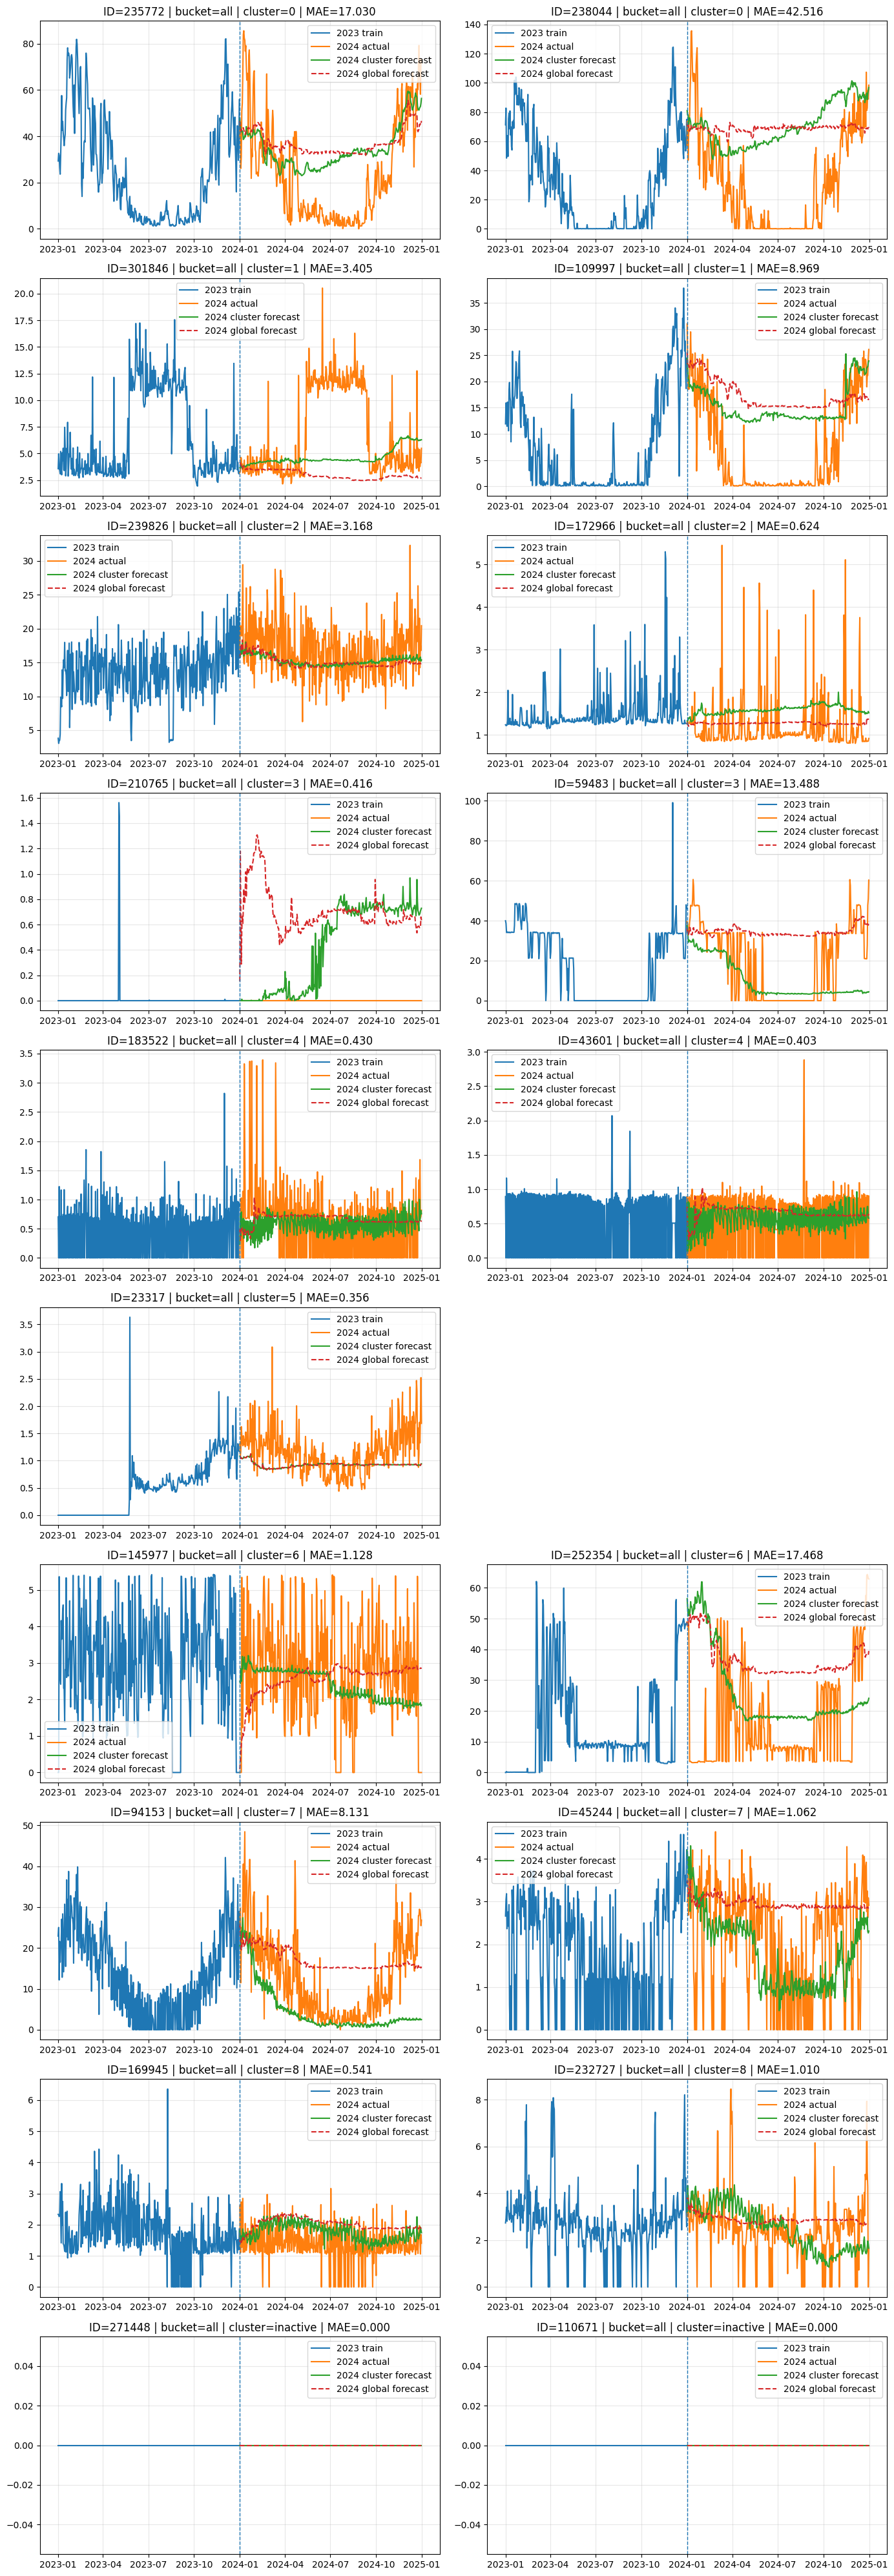

,ID,SparsityBucket,ForecastGroup,MAE
0,235772,all,0,17.029634
1,238044,all,0,42.516222
2,301846,all,1,3.404660
3,109997,all,1,8.969131
4,239826,all,2,3.167939
5,172966,all,2,0.623623
6,210765,all,3,0.415816
7,59483,all,3,13.487933
8,183522,all,4,0.429606
9,43601,all,4,0.403452


In [34]:
sampled_households, fig = plot_random_households_by_bucket_and_cluster(
    train_23_wide=train_23,
    test_24_wide=test_24,
    pred_cluster_wide=pred_cluster_xgb,
    cluster_labels=cluster_labels,
    mae_cluster_df=mae_cluster,
    pred_global_wide=pred_global_xgb,   # optional, but useful
    bucket_col="SparsityBucket",        # change if your CSV uses another bucket column name
    cluster_col="ForecastGroup",
    n_per_group=2,
    random_state=42,
    max_groups=None,
)

display(sampled_households)

In [35]:
plot_path = OUT["plots"] / "sample_households_by_bucket_cluster_xgb.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
print(f"Saved plot to: {plot_path}")

Saved plot to: /kaggle/working/Clustering-And-Forecasting-TimeSeries-PlayingGround/outputs/plots/sample_households_by_bucket_cluster_xgb.png
